In [1]:
!pip install openneuro-py nilearn pandas matplotlib seaborn nibabel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.0 MB/s eta 0:00:00


In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_design_matrix, plot_stat_map

In [3]:
os.makedirs("data/raw/sub-01", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [4]:
!openneuro-py download \
  --dataset=ds000115 \
  --include sub-01 \
  --target-dir data/raw


👋 Hello! This is openneuro-py 2026.4.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds000115 …
Cannot determine local revision of the dataset, and the target directory is not empty. If the download fails, you may want to try again with a fresh (empty) target directory.
📁 Traversing directories for ds000115 : 15 entities [00:00, 71.95 entities/s]
📥 Retrieving up to 11 files (5 concurrent downloads). 
participants.tsv:   0% 0.00/26.6k [00:00<?, ?B/s]
dataset_description.json:   0% 0.00/215 [00:00<?, ?B/s]
sub-01_T1w.nii.gz:   0% 0.00/33.6M [00:00<?, ?B/s]
sub-01_task-letter0backtask_bold.nii.gz:   0% 0.00/19.0M [00:00<?, ?B/s]

sub-01_task-letter2backtask_bold.nii.gz:   0% 0.00/19.0M [00:00<?, ?B/s]


sub-01_T1w.nii.gz:   1% 305k/33.6M [00:00<00:11, 3.04MB/s]
sub-01_task-letter0backtask_bold.nii.gz:   2% 373k/19.0M [00:00<00:05, 3.65MB/s]

sub-01_task-letter2backtask_bold.nii.gz:   2%

In [5]:
bold_files = glob.glob(
    "data/raw/**/**/*bold.nii.gz",
    recursive=True
)

event_files = glob.glob(
    "data/raw/**/**/*events.tsv",
    recursive=True
)

print("BOLD files found:")
print(bold_files[:10])

print("\nEvent files found:")
print(event_files[:10])

BOLD files found:
['data/raw/sub-01/func/sub-01_task-letter1backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter0backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter2backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter1backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter0backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter2backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter1backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter0backtask_bold.nii.gz', 'data/raw/sub-01/func/sub-01_task-letter2backtask_bold.nii.gz']

Event files found:
['data/raw/sub-01/func/sub-01_task-letter0backtask_events.tsv', 'data/raw/sub-01/func/sub-01_task-letter2backtask_events.tsv', 'data/raw/sub-01/func/sub-01_task-letter1backtask_events.tsv', 'data/raw/sub-01/func/sub-01_task-letter0backtask_events.tsv', 'data/raw/sub-01/func/sub-01_task-letter2backtask_events.tsv', 'data/raw/sub-01/func/sub-01_task-letter1backtask_events.tsv', 'data/

In [6]:
fmri_img = bold_files[0]
events_path = event_files[0]

print("Using BOLD:", fmri_img)
print("Using Events:", events_path)

Using BOLD: data/raw/sub-01/func/sub-01_task-letter1backtask_bold.nii.gz
Using Events: data/raw/sub-01/func/sub-01_task-letter0backtask_events.tsv


In [7]:
events = pd.read_csv(events_path, sep="\t")
events.head()

,onset,duration,trial_type,nback-nontarget,response_time
0,27.5,0.655357,nback-nontarget,0.714286,0.0
1,30.0,0.655357,nback-nontarget,-0.285714,0.0
2,37.5,0.655357,nback-nontarget,-0.285714,0.0
3,42.5,0.655357,nback-nontarget,-0.285714,0.0
4,47.5,0.655357,nback-nontarget,-0.285714,0.0


In [14]:
events = events[["onset", "duration", "trial_type"]]
events.head()

,onset,duration,trial_type
0,27.5,0.655357,nback-nontarget
1,30.0,0.655357,nback-nontarget
2,37.5,0.655357,nback-nontarget
3,42.5,0.655357,nback-nontarget
4,47.5,0.655357,nback-nontarget


In [15]:
glm = FirstLevelModel(
    t_r=2.0,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    smoothing_fwhm=6
)

glm = glm.fit(fmri_img, events=events)

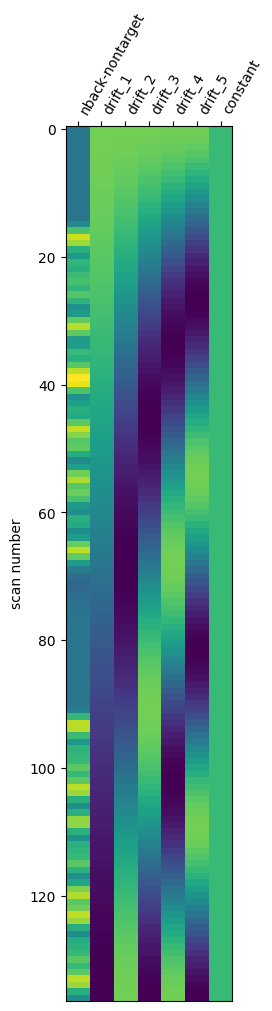

In [16]:
design_matrix = glm.design_matrices_[0]

plot_design_matrix(design_matrix)
plt.show()

In [18]:
print(design_matrix.columns.tolist())

['nback-nontarget', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'constant']


In [19]:
contrast_name = design_matrix.columns[0]
print("Contrast:", contrast_name)

z_map = glm.compute_contrast(
    contrast_name,
    output_type="z_score"
)

Contrast: nback-nontarget


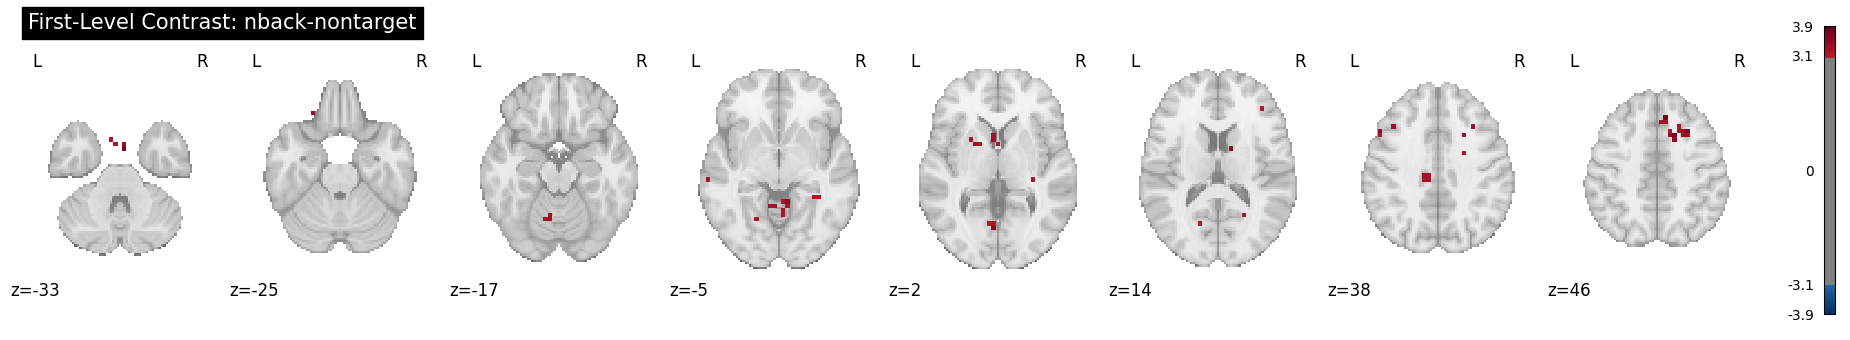

In [20]:
plot_stat_map(
    z_map,
    threshold=3.1,
    display_mode="z",
    cut_coords=8,
    title=f"First-Level Contrast: {contrast_name}"
)

plt.show()

Saved figure


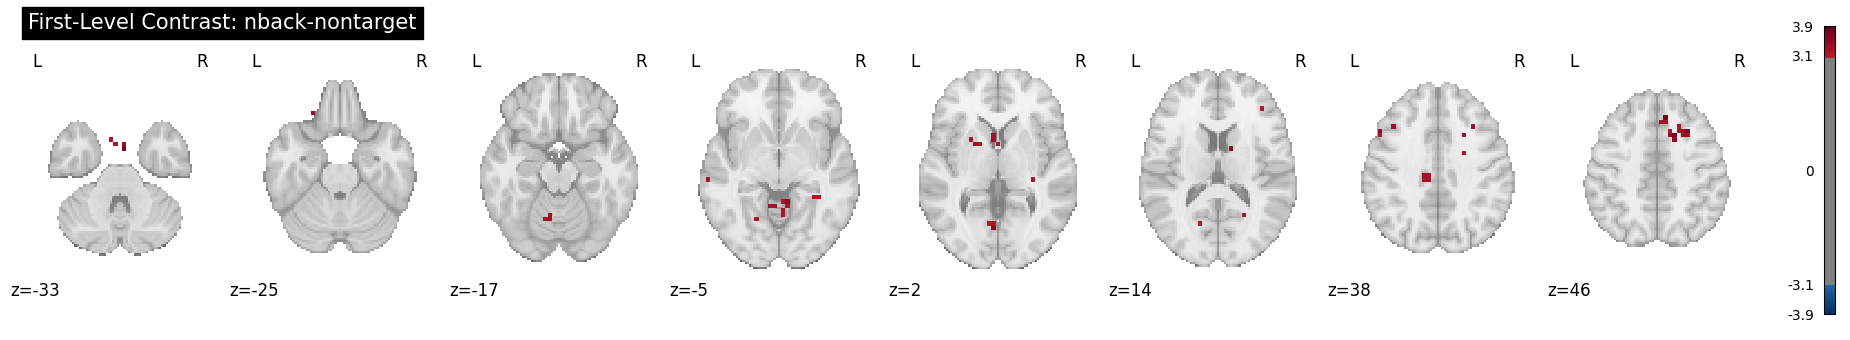

In [21]:
fig = plot_stat_map(
    z_map,
    threshold=3.1,
    display_mode="z",
    cut_coords=8,
    title=f"First-Level Contrast: {contrast_name}"
)

fig.savefig("figures/first_level_activation.png")
print("Saved figure")